# Positive Count as a Driver of Synthetic Data Fidelity: A Controlled Simulation

The MIMIC notebook has no ground truth, so it can only compare real against
synthetic. Here the truth is known: the population is generated from a fixed
data-generating process, and every estimate can be scored against the value that
went in.

Same design as the MIMIC sweeps, one lever: sample size is fixed at 500, the CHF
positive count is varied, and the whole grid is repeated at three true effect
sizes to check the pattern is not specific to one.

In [2]:
library(synthpop)
library(dplyr)
library(ggplot2)
library(tidyr)

## Population & Ground Truth

`generate_population()` builds the pool and puts a known `chf:lactate`
interaction into the logit. `effect_size` is the true value, so anything the
sweep recovers can be scored against it directly.

`N` is 20,000, not 5,000. At 8% prevalence a 5,000-row pool holds only about
400 positives, so a `k = 250` draw takes 62% of them and the replicates
overlap heavily. That narrows the IQR at high `k` for reasons that have
nothing to do with information. At 20,000 the same draw takes 16%. MIMIC-IV
never had this problem: COPD alone has 7,244 positives.

No `EXPLODE_THRESHOLD` is set here. `run_one_trial()` returns the raw
estimates and the divergence flag is applied at summary time, so the cutoff
can be varied without re-running the sweep.

In [3]:
generate_population <- function(effect_size, N = 20000, seed = 42) {
  set.seed(seed)
  pop <- data.frame(
    age     = rnorm(N, 65, 15),
    lactate = rnorm(N, 2, 1),
    chf     = rbinom(N, 1, 0.08)
  )
  # DGP: chf:lactate true value = effect_size, only in the CHF=1 stratum
  logit_p <- -3 + 0.02*pop$age + 0.3*pop$lactate +
             pop$chf*(2 + effect_size*pop$lactate)
  pop$mortality <- rbinom(N, 1, plogis(logit_p))
  pop
}

## Functions

`get_interaction()` pulls the one coefficient out of a fit, `run_one_trial()`
does the draw-synthesise-fit cycle once.

### get_interaction()

In [4]:
get_interaction <- function(df) {
  fit <- suppressWarnings(
    glm(mortality ~ age + lactate + chf + chf:lactate,
        data = df, family = binomial)
  )
  coef(fit)["lactate:chf"]
}

### run_one_trial()

In [5]:
run_one_trial <- function(k, seed, n_fixed, pos_pool, neg_pool) {
  set.seed(seed)

  sub <- rbind(pos_pool[sample(nrow(pos_pool), k), ],
               neg_pool[sample(nrow(neg_pool), n_fixed - k), ])

  # cast binaries to factor so synthpop treats them as categorical
  sub$chf       <- factor(sub$chf)
  sub$mortality <- factor(sub$mortality)

  syn_obj <- syn(sub, seed = seed, print.flag = FALSE)
  syn     <- syn_obj$syn

  # cast back to numeric for the glm probe (factor coding renames the
  # interaction term to "lactate:chf1", which breaks coef(fit)["lactate:chf"])
  sub$chf       <- as.numeric(as.character(sub$chf))
  sub$mortality <- as.numeric(as.character(sub$mortality))
  syn$chf       <- as.numeric(as.character(syn$chf))
  syn$mortality <- as.numeric(as.character(syn$mortality))

  # no divergence flag here: the raw estimates are returned and the cutoff is
  # applied at summary time, so it can be varied without re-running the sweep
  data.frame(
    count    = k,
    rep      = seed,
    real_est = get_interaction(sub),
    syn_est  = get_interaction(syn)
  )
}

## Sweep: Effect Size × Positive Count

3 effect sizes x 7 counts x 200 replicates. The population is regenerated
once per effect size, then the counts and replicates loop inside it.

`seed = k * 1000 + r` gives every trial a distinct seed and keeps the same
trial reproducible across runs. The MIMIC notebook uses the same convention.

M is 200 rather than 50 because the summaries now carry intervals: 0 of 50
bounds a rate only at 7.1%, 0 of 200 at 1.8%. The cost is 4,200 `syn()`
calls, roughly four times the previous run.

In [6]:
EFFECT_SIZES <- c(0.5, 1.5, 3)
counts       <- c(5, 10, 20, 40, 80, 150, 250)
n_fixed      <- 500
M            <- 200

all_results <- lapply(EFFECT_SIZES, function(eff) {
  pop <- generate_population(eff)
  pos_pool <- pop[pop$chf == 1, ]
  neg_pool <- pop[pop$chf == 0, ]

  eff_results <- lapply(counts, function(k) {
    lapply(seq_len(M), function(r) {
      run_one_trial(k, seed = k * 1000 + r, n_fixed, pos_pool, neg_pool)
    }) %>% bind_rows()
  }) %>% bind_rows()

  eff_results$effect_size <- eff
  eff_results$true        <- eff
  eff_results
}) %>% bind_rows()

# how many positives each population holds, so the k = 250 draw can be
# checked against the pool it comes from
sapply(EFFECT_SIZES, function(eff) sum(generate_population(eff)$chf))

[1] 1554 1554 1554

In [7]:
summarise_at_cutoff <- function(results, cut_at) {
  results %>%
    mutate(real_exploded = abs(real_est) > cut_at,
           syn_exploded  = abs(syn_est)  > cut_at) %>%
    group_by(effect_size, count) %>%
    summarise(
      real_pct_exploded = round(100 * mean(real_exploded, na.rm = TRUE), 1),
      syn_pct_exploded  = round(100 * mean(syn_exploded,  na.rm = TRUE), 1),
      # medians over the converged runs only: typical behaviour when the fit
      # works, kept separate from how often it does not
      real_median       = median(real_est[!real_exploded], na.rm = TRUE),
      syn_median        = median(syn_est[!syn_exploded],   na.rm = TRUE),
      real_error_median = median(abs(real_est - effect_size)[!real_exploded], na.rm = TRUE),
      syn_error_median  = median(abs(syn_est  - effect_size)[!syn_exploded],  na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(cutoff = cut_at, .before = effect_size)
}

# the MIMIC notebook uses |2| against a target of ~0.05, forty times the
# truth. Here the truth spans 0.5 to 3, so no single constant matches that
# ratio; the sweep is reported at four cutoffs instead and the comparisons
# are checked for agreement.
CUTOFFS <- c(5, 10, 20, 40)

summary_all <- bind_rows(lapply(CUTOFFS, summarise_at_cutoff, results = all_results))

summary_df <- summary_all %>% filter(cutoff == 10)
print(summary_df, n = Inf, width = Inf)

# A tibble: 21 × 9
   cutoff effect_size count real_pct_exploded syn_pct_exploded real_median
    <dbl>       <dbl> <dbl>             <dbl>            <dbl>       <dbl>
 1     10         0.5     5              23               24.4     -0.237 
 2     10         0.5    10              14.5             13        0.0728
 3     10         0.5    20               3                4.5      0.584 
 4     10         0.5    40               0                0.5      0.559 
 5     10         0.5    80               0                0        0.591 
 6     10         0.5   150               0                0        0.550 
 7     10         0.5   250               0                0        0.521 
 8     10         1.5     5              16.5             19.7     -0.268 
 9     10         1.5    10              20                5.5     -0.222 
10     10         1.5    20              21.5              4        0.715 
11     10         1.5    40              14.5              6        1.51  
12    

## Results

Three views of the same sweep: how close the estimate lands, how often the fit
diverges, and how the two relate.

### Median Estimate vs Positive Count

Dashed line is the true value for that panel. Distance from it is bias, which is
only measurable because the truth is known.

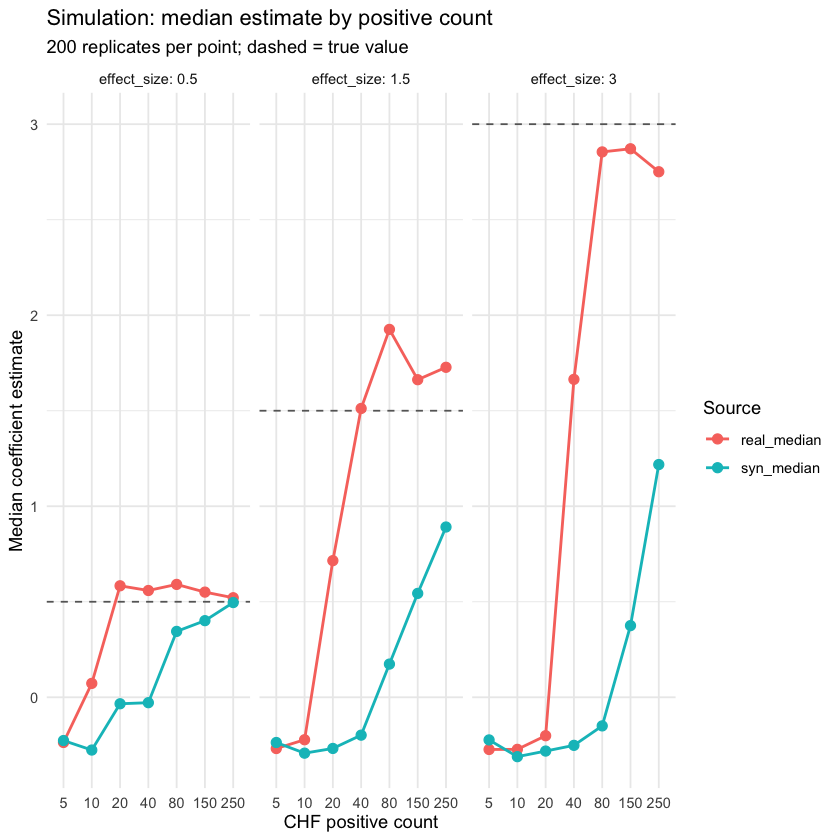

In [9]:
median_long <- summary_df %>%
  select(effect_size, count, real_median, syn_median) %>%
  pivot_longer(c(real_median, syn_median), names_to = "source", values_to = "coef")

hline_df <- data.frame(effect_size = EFFECT_SIZES, true = EFFECT_SIZES)

# factor(count) rather than a continuous axis: on a linear scale 5, 10, 20 and
# 40 collide, and that is exactly the range where the sign is still wrong
p_sim_median <- ggplot(median_long, aes(factor(count), coef,
                                        color = source, group = source)) +
  geom_hline(data = hline_df, aes(yintercept = true),
             linetype = "dashed", color = "grey40") +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2.5) +
  facet_wrap(~ effect_size, labeller = label_both) +
  labs(title = "Simulation: median estimate by positive count",
       subtitle = "200 replicates per point; dashed = true value",
       x = "CHF positive count", y = "Median coefficient estimate",
       color = "Source") +
  theme_minimal()
p_sim_median

# exported so the report can show the whole curve rather than the k = 250 row
# alone: at a true value of 3 the synthetic median runs from -0.150 at k = 80
# to 1.22 at k = 250, and a single-count table hides that swing
ggsave("../figures/sim_median.png", p_sim_median, width = 9, height = 3.6, dpi = 150)
